# Visualization Notebook
- imports and shared settings
- reads the processed master file
- saves figures into `outputs/figures/`


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
from matplotlib.patches import Ellipse
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from adjustText import adjust_text

ME_REGION = "Middle East"
ME_COLOR  = "#FF4500"
ME_DARK   = "#8B0000"  

OUTPUT_DIR = Path("outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUTPUT_DIR / "processed_all_master.csv"
df = pd.read_csv(DATA_PATH)

df["country_name"] = df["country_name"].str.strip()
df["region"] = df["region"].str.strip()

spelling_corrections = {
    "Türkiye": "Turkey",
    "Turkiye": "Turkey",
    "Iran, Islamic Republic of": "Iran",
    "Iran (Islamic Republic of)": "Iran",
    "Syrian Arab Republic": "Syria",
    "Egypt, Arab Rep.": "Egypt",
    "Palestine, State of": "Palestine",
    "Gaza Strip and West Bank": "Palestine"
}
df["country_name"] = df["country_name"].replace(spelling_corrections)

TARGET_COUNTRIES = [
    "Saudi Arabia", "United Arab Emirates", "Oman", "Kuwait", "Qatar", 
    "Bahrain", "Jordan", "Egypt", "Palestine", "Iran", "Iraq", "Lebanon", "Syria", 
    "Turkey", "Cyprus", "Israel"
]

df.loc[df["region"] == ME_REGION, "region"] = "Other"

df.loc[df["country_name"].isin(TARGET_COUNTRIES), "region"] = ME_REGION

me_mask = df["region"] == ME_REGION
df.loc[me_mask, "country_name"] = df.loc[me_mask, "country_name"].apply(
    lambda x: next((target for target in TARGET_COUNTRIES if target.lower() == x.lower()), x)
)

all_regions = sorted(df["region"].unique())
base_palette = sns.color_palette("tab10", n_colors=len(all_regions))
region_palette = {r: base_palette[i] for i, r in enumerate(all_regions)}
region_palette[ME_REGION] = ME_COLOR

matched_me = df[df["region"] == ME_REGION]["country_name"].unique().tolist()

ME_MARKER = "*"     
ME_SIZE   = 260     
ME_ALPHA  = 1.0   

ME_LABELS = TARGET_COUNTRIES


# Scatterplots
- Figure 4.1: obesity vs cancer ASR
- Figure 4.2: physical activity vs cancer ASR
- Figure 4.3: log GDP vs cancer ASR


In [7]:
def make_scatterplot_figure(x_col, y_col, x_label, title, out_path, fig_id):
    fig, ax = plt.subplots(figsize=(10, 7))
    
    non_me = df[df["region"] != ME_REGION]
    for region, grp in non_me.groupby("region"):
        ax.scatter(
            grp[x_col], grp[y_col],
            color=region_palette[region],
            s=45, alpha=0.55, linewidths=0.3, edgecolors="white",
            label=region, zorder=2,
        )
        
    sns.regplot(
        data=df, x=x_col, y=y_col,
        scatter=False,          
        ax=ax,
        line_kws={"color": "#2c2c2c", "lw": 2.2, "linestyle": "--", "label": "Global trend (OLS)"},
        ci=95,
        color="#2c2c2c",
    )

    me = df[df["region"] == ME_REGION].copy()
    ax.scatter(
        me[x_col], me[y_col],
        color=ME_COLOR, marker=ME_MARKER,
        s=ME_SIZE, alpha=ME_ALPHA,
        linewidths=0.5, edgecolors=ME_DARK,
        zorder=5, label=ME_REGION,
    )

    label_rows = me[me["country_name"].isin(ME_LABELS)]
    texts = []
    for _, row in label_rows.iterrows():
        txt = ax.text(
            row[x_col], row[y_col],
            row["country_name"],
            fontsize=8.5, color=ME_DARK, fontweight="bold",
            ha="left", va="bottom",
            zorder=6,
        )
        texts.append(txt)

    if texts:
        adjust_text(
            texts, ax=ax,
            arrowprops=dict(arrowstyle="-", color=ME_DARK, lw=0.8),
            expand_text=(1.3, 1.5),
            expand_points=(1.4, 1.6),
        )

    ax.set_xlabel(x_label, labelpad=8)
    ax.set_ylabel("Age-Standardised Cancer Rate (ASR, World)", labelpad=8)
    ax.set_title(f"{fig_id}: {title}", pad=14)

    handles, labels = ax.get_legend_handles_labels()
    line_handle  = [h for h, l in zip(handles, labels) if l == "Global trend (OLS)"]
    line_label   = ["Global trend (OLS)"]
    region_handles = [h for h, l in zip(handles, labels) if l not in ("Global trend (OLS)", ME_REGION)]
    region_labels  = [l for l in labels if l not in ("Global trend (OLS)", ME_REGION)]

    me_handle = mpatches.Patch(color=ME_COLOR, label=f"{ME_REGION} ★")

    all_handles = region_handles + [me_handle] + line_handle
    all_labels  = region_labels  + [f"{ME_REGION} ★"] + line_label

    legend = ax.legend(
        all_handles, all_labels,
        title="Region",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        frameon=True,
        framealpha=0.92,
        edgecolor="#cccccc",
    )
    legend.get_title().set_fontweight("bold")

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout(rect=[0, 0, 0.82, 1])
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


make_scatterplot_figure(
    x_col    = "obesity_value",
    y_col    = "asr_world",
    x_label  = "Obesity Prevalence (%)",
    title    = "Obesity Prevalence vs. Age-Standardised Cancer Rate",
    out_path = FIGURE_DIR / "figure_4_1_obesity_vs_asr.png",
    fig_id   = "Figure 4.1",
)

make_scatterplot_figure(
    x_col    = "activity_value",
    y_col    = "asr_world",
    x_label  = "Physical Activity Level (% sufficiently active)",
    title    = "Physical Activity vs. Age-Standardised Cancer Rate",
    out_path = FIGURE_DIR / "figure_4_2_activity_vs_asr.png",
    fig_id   = "Figure 4.2",
)

make_scatterplot_figure(
    x_col    = "log_gdp",
    y_col    = "asr_world",
    x_label  = "Log GDP per Capita (ln USD)",
    title    = "Log GDP per Capita vs. Age-Standardised Cancer Rate",
    out_path = FIGURE_DIR / "figure_4_3_loggdp_vs_asr.png",
    fig_id   = "Figure 4.3",
)

# Extra Relationship Plots
- Figure 4.4: obesity and GDP overlap, bubble size by cancer ASR
- Figure 4.5: GDP vs obesity, Middle East highlighted


In [8]:
def generate_figure_5_4():
    fig, ax = plt.subplots(figsize=(11, 7.5))

    asr = df["asr_world"]
    size_min, size_max = 25, 420
    sizes = size_min + (asr - asr.min()) / (asr.max() - asr.min()) * (size_max - size_min)

    ellipse = Ellipse(
        xy=(36, 9.5),
        width=22,
        height=3.6,
        angle=0,
        linewidth=1.8,
        edgecolor=ME_COLOR,
        facecolor="none",
        linestyle="--",
        zorder=4,
    )
    ax.add_patch(ellipse)
    
    ax.annotate(
        "Middle East Cluster\n(High Obesity × Varied GDP)",
        xy=(40, 9.0),
        xytext=(46, 8.9),
        fontsize=9, color=ME_COLOR, fontweight="bold",
        ha="left", va="center",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white", edgecolor=ME_COLOR,
            linewidth=1.6, alpha=0.92,
        ),
        arrowprops=dict(
            arrowstyle="-|>",
            color=ME_COLOR, lw=1.5,
            connectionstyle="arc3,rad=-0.15",
        ),
        zorder=8,
    )

    non_me = df[df["region"] != ME_REGION].copy()
    non_me_sizes = size_min + ((non_me["asr_world"] - asr.min()) / (asr.max() - asr.min())) * (size_max - size_min)

    for region, grp in non_me.groupby("region"):
        idx = grp.index
        ax.scatter(
            grp["obesity_value"], grp["log_gdp"],
            s=non_me_sizes[idx],
            color=region_palette[region],
            alpha=0.52, linewidths=0.3, edgecolors="white",
            label=region, zorder=2,
        )

    me = df[df["region"] == ME_REGION].copy()
    me_sizes = size_min + ((me["asr_world"] - asr.min()) / (asr.max() - asr.min())) * (size_max - size_min)

    ax.scatter(
        me["obesity_value"], me["log_gdp"],
        s=me_sizes,
        color=ME_COLOR,
        marker="D",
        alpha=0.95,
        linewidths=0.7, edgecolors=ME_DARK,
        label=ME_REGION, zorder=5,
    )
    
    label_rows = me[me["country_name"].isin(ME_LABELS)]
    texts = []
    for _, row in label_rows.iterrows():
        t = ax.text(
            row["obesity_value"], row["log_gdp"],
            row["country_name"],
            fontsize=8, color=ME_DARK, fontweight="bold",
            ha="left", va="bottom", zorder=7,
        )
        texts.append(t)

    if texts:
        adjust_text(
            texts, ax=ax,
            arrowprops=dict(arrowstyle="-", color=ME_DARK, lw=0.75),
            expand_text=(1.25, 1.5),
            expand_points=(1.35, 1.55),
        )
        
    ref_asr = [asr.quantile(0.1), asr.quantile(0.5), asr.quantile(0.9)]
    ref_sizes = [size_min + (v - asr.min()) / (asr.max() - asr.min()) * (size_max - size_min) for v in ref_asr]
    size_handles = [
        mlines.Line2D([], [], color="grey", marker="o", linestyle="None",
                      markersize=np.sqrt(s), alpha=0.6, label=f"ASR ≈ {v:.0f}")
        for s, v in zip(ref_sizes, ref_asr)
    ]

    region_handles = []
    for region in sorted(df["region"].unique()):
        marker = "D" if region == ME_REGION else "o"
        h = mlines.Line2D(
            [], [], color=region_palette[region],
            marker=marker, linestyle="None", markersize=7,
            label=region,
            markeredgecolor=ME_DARK if region == ME_REGION else "white",
            markeredgewidth=0.6,
        )
        region_handles.append(h)

    leg1 = ax.legend(
        handles=region_handles, title="Region  (◆ = Middle East)",
        loc="upper left", bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0, frameon=True, framealpha=0.93, edgecolor="#cccccc",
    )
    leg1.get_title().set_fontweight("bold")

    leg2 = ax.legend(
        handles=size_handles, title="Bubble size = ASR",
        loc="upper left", bbox_to_anchor=(1.01, 0.38),
        borderaxespad=0, frameon=True, framealpha=0.93, edgecolor="#cccccc",
    )
    leg2.get_title().set_fontweight("bold")
    ax.add_artist(leg1)

    ax.set_xlabel("Obesity Prevalence (%)", labelpad=8)
    ax.set_ylabel("Log GDP per Capita (ln USD)", labelpad=8)
    ax.set_title("Figure 4.4: Obesity Prevalence vs. Log GDP per Capita\n(bubble size ∝ Age-Standardised Cancer Rate)", pad=14)
    ax.grid(True, linestyle="--", linewidth=0.55, alpha=0.65)
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout(rect=[0, 0, 0.80, 1])
    fig.savefig(FIGURE_DIR / "figure_4_4_predictor_overlap.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

generate_figure_5_4()

## GDP and Obesity
Middle East highlighted against the global pattern.


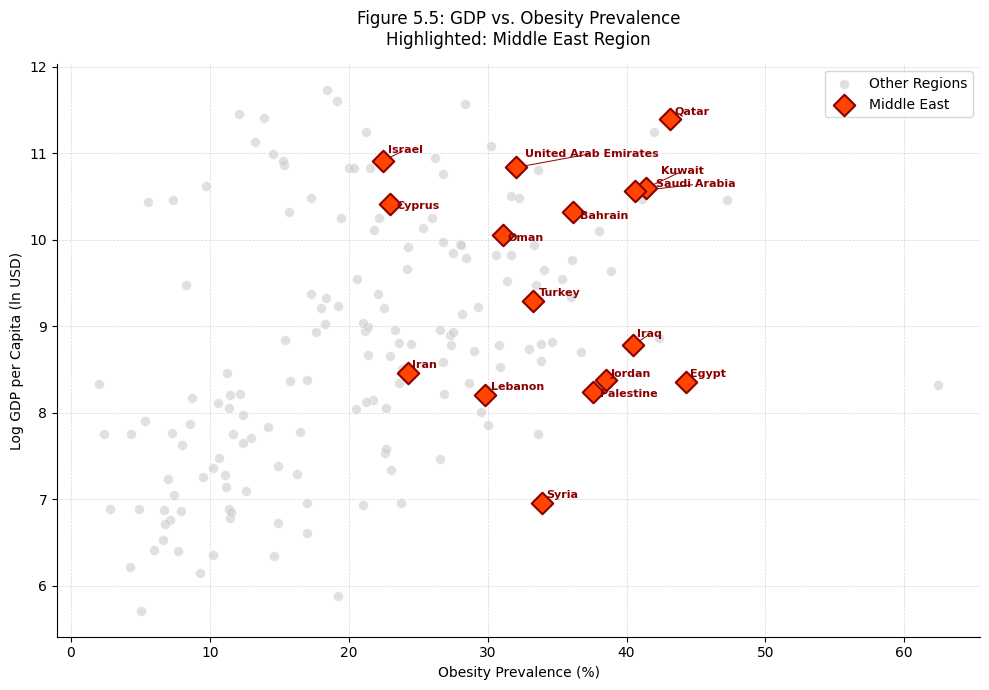

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

non_me = df[df["region"] != ME_REGION]
ax.scatter(
    non_me["obesity_value"], non_me["log_gdp"],
    color="#cccccc", s=50, alpha=0.6, edgecolors="white", linewidth=0.5,
    label="Other Regions", zorder=2
)

me = df[df["region"] == ME_REGION]
ax.scatter(
    me["obesity_value"], me["log_gdp"],
    color=ME_COLOR, marker="D", s=120, edgecolors=ME_DARK, linewidth=1.5,
    label="Middle East", zorder=5
)

label_rows = me[me["country_name"].isin(ME_LABELS)]
texts = []
for _, row in label_rows.iterrows():
    t = ax.text(
        row["obesity_value"], row["log_gdp"],
        row["country_name"],
        fontsize=8, color=ME_DARK, fontweight="bold",
        ha="left", va="bottom", zorder=7
    )
    texts.append(t)

if texts:
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", color=ME_DARK, lw=0.7),
        expand_text=(1.2, 1.4),
        expand_points=(1.3, 1.5)
    )
    
ax.set_xlabel("Obesity Prevalence (%)")
ax.set_ylabel("Log GDP per Capita (ln USD)")
ax.set_title("Figure 4.5: GDP vs. Obesity Prevalence\nHighlighted: Middle East Region", pad=14)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
    
ax.legend(loc="best", frameon=True, edgecolor="#cccccc")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_4_5_gdp_vs_obesity.png", dpi=300, bbox_inches="tight")
plt.close(fig)

# Correlation Heatmap
Pearson correlation for the main variables.


In [10]:
CORE_VARS = ["asr_world", "obesity_value", "activity_value", "log_gdp"]
df_core = df[CORE_VARS].dropna()

HEATMAP_LABELS = {
    "asr_world": "Cancer Incidence\n(ASR, World Std.)",
    "obesity_value": "Obesity\nPrevalence (%)",
    "activity_value": "Physical Activity\nPrevalence (%)",
    "log_gdp": "Log GDP\nper Capita",
}
display_labels = [HEATMAP_LABELS[v] for v in CORE_VARS]

corr = df_core.corr(method="pearson")
n_countries = len(df_core)

pval = pd.DataFrame(np.ones_like(corr.values), index=corr.index, columns=corr.columns)
for r in CORE_VARS:
    for c in CORE_VARS:
        if r != c:
            _, p = stats.pearsonr(df_core[r], df_core[c])
            pval.loc[r, c] = p

def sig_stars(p: float) -> str:
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

annot = pd.DataFrame("", index=corr.index, columns=corr.columns)
for r in CORE_VARS:
    for c in CORE_VARS:
        if r == c:
            annot.loc[r, c] = "1.00"
        else:
            stars = sig_stars(pval.loc[r, c])
            annot.loc[r, c] = f"{corr.loc[r, c]:.2f}\n{stars}" if stars else f"{corr.loc[r, c]:.2f}"

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(7.5, 6.5))

with plt.rc_context({"font.family": "serif"}):
    hm = sns.heatmap(
        corr,
        mask=mask,
        cmap="RdBu_r",
        vmin=-1, vmax=1, center=0,
        annot=annot, fmt="",
        annot_kws={"size": 11, "weight": "bold"},
        linewidths=1.5, linecolor="white", square=True,
        cbar_kws={
            "shrink": 0.78,
            "aspect": 18,
            "pad": 0.03,
            "label": "Pearson  r",
            "ticks": [-1, -0.5, 0, 0.5, 1],
        },
        ax=ax,
    )

    ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=10, linespacing=1.4)
    ax.set_yticklabels(display_labels, rotation=0, va="center", fontsize=10, linespacing=1.4)
    ax.tick_params(axis="x", pad=6, length=0)
    ax.tick_params(axis="y", pad=8, length=0)

    cbar = hm.collections[0].colorbar
    cbar.ax.set_ylabel("Pearson  r", fontsize=10, labelpad=10)
    cbar.ax.tick_params(labelsize=9)

    sig_text = "Significance:  * p < .05     ** p < .01     *** p < .001"
    fig.text(0.13, -0.02, sig_text, fontsize=8.5, fontstyle="italic", color="#444444")
    fig.text(0.13, -0.055, f"n = {n_countries} countries  |  Pearson correlation  |  pairwise complete observations", fontsize=8, color="#666666")

    ax.set_title(
        "Figure 4.6  |  Correlation Matrix of Core Predictors\n"
        "Cancer Incidence, Obesity, Physical Activity, and Economic Development",
        pad=16, linespacing=1.6, fontsize=13, weight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel("")

    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "figure_4_6_correlation_heatmap.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

# PCA Scree Plot
Explained variance across the four z-score variables.


In [11]:
Z_COLS = ["z_cancer_index", "z_obesity", "z_physical_activity", "z_log_gdp"]
X = df[Z_COLS].dropna()

pca = PCA(n_components=len(Z_COLS), random_state=42)
pca.fit(X)

n_components = pca.n_components_
evr = pca.explained_variance_ratio_          
cumulative_evr = np.cumsum(evr)              
component_labels = [f"PC{i+1}" for i in range(n_components)]

BAR_COLOR       = "#4C78A8"   
BAR_COLOR_TOP   = "#FF4500" 
LINE_COLOR      = "#2ca02c" 
MARKER_COLOR    = "#1a6e1a"  
ANNOT_COLOR     = "#1a1a2e"  
THRESHOLD_COLOR = "#FF4500" 

fig, ax_bar = plt.subplots(figsize=(9, 6))

x_pos = np.arange(n_components)
bar_width = 0.55
bar_colors = [BAR_COLOR_TOP if i == 0 else BAR_COLOR for i in range(n_components)]

bars = ax_bar.bar(
    x_pos, evr * 100,
    width=bar_width,
    color=bar_colors, alpha=0.88,
    edgecolor="white", linewidth=0.8,
    zorder=3, label="Individual Explained Variance (%)",
)

for bar, val in zip(bars, evr * 100):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val:.2f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
        color=ANNOT_COLOR, zorder=5,
    )

ax_bar.set_xlabel("Principal Component", labelpad=8)
ax_bar.set_ylabel("Individual Explained Variance (%)", labelpad=8, color=BAR_COLOR)
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(component_labels)
ax_bar.set_ylim(0, max(evr * 100) * 1.22)
ax_bar.tick_params(axis="y", labelcolor=BAR_COLOR)
ax_bar.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax_bar.grid(axis="y", linestyle="--", linewidth=0.55, alpha=0.6, zorder=0)
ax_bar.set_axisbelow(True)

for spine in ["top", "right"]:
    ax_bar.spines[spine].set_visible(False)

ax_line = ax_bar.twinx()
ax_line.plot(
    x_pos, cumulative_evr * 100,
    color=LINE_COLOR, linewidth=2.4, linestyle="-",
    marker="D", markersize=8, markerfacecolor=MARKER_COLOR,
    markeredgecolor="white", markeredgewidth=1.0,
    zorder=4, label="Cumulative Explained Variance (%)",
)

for xi, cum_val in zip(x_pos, cumulative_evr * 100):
    offset_y = -5.5 if xi == x_pos[-1] else 2.5
    ax_line.annotate(
        f"{cum_val:.1f}%",
        xy=(xi, cum_val), xytext=(xi + 0.05, cum_val + offset_y),
        fontsize=9, color=MARKER_COLOR, fontweight="bold", ha="left",
    )

for threshold, ls, label in [(80, "--", "80% threshold"), (95, ":", "95% threshold")]:
    ax_line.axhline(threshold, color=THRESHOLD_COLOR, linewidth=1.2, linestyle=ls, alpha=0.75, zorder=2, label=label)
    ax_line.text(x_pos[-1] + 0.35, threshold + 0.8, f"{threshold}%", fontsize=8.5, color=THRESHOLD_COLOR, va="bottom", ha="left")

ax_line.set_ylabel("Cumulative Explained Variance (%)", labelpad=8, color=LINE_COLOR)
ax_line.set_ylim(0, 112)
ax_line.tick_params(axis="y", labelcolor=LINE_COLOR)
ax_line.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

for spine in ["top"]:
    ax_line.spines[spine].set_visible(False)

handles_bar, labels_bar = ax_bar.get_legend_handles_labels()
handles_line, labels_line = ax_line.get_legend_handles_labels()

fig.legend(
    handles_bar + handles_line, labels_bar + labels_line,
    loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=2,
    frameon=True, framealpha=0.93, edgecolor="#cccccc",
)

ax_bar.set_title(
    "Figure 4.7: PCA Scree Plot: Explained Variance by Component\n"
    f"(n = {len(X)} countries; features: z_cancer_index, z_obesity, z_physical_activity, z_log_gdp)",
    pad=14,
)

out_path = FIGURE_DIR / "figure_4_7_pca_scree.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.close(fig)

# PCA Loadings Biplot
Feature directions for PC1 and PC2.


In [12]:
Z_COLS = ["z_cancer_index", "z_obesity", "z_physical_activity", "z_log_gdp"]
LABELS = ["Cancer Index",   "Obesity",   "Physical Activity",   "Log GDP"]

X = df[Z_COLS].dropna()

pca = PCA(n_components=4, random_state=42)
pca.fit(X)

evr = pca.explained_variance_ratio_
loadings = pca.components_.T
pc1_load = loadings[:, 0]
pc2_load = loadings[:, 1]

ARROW_COLORS = {
    "Cancer Index": "#E63946",  
    "Obesity": "#FF4500",
    "Physical Activity": "#457B9D", 
    "Log GDP": "#2CA02C", 
}
LABEL_PAD = 0.055

fig, ax = plt.subplots(figsize=(8, 8))

ax.axhline(0, color="#aaaaaa", linewidth=0.9, linestyle="--", zorder=1)
ax.axvline(0, color="#aaaaaa", linewidth=0.9, linestyle="--", zorder=1)

circle = plt.Circle((0, 0), 1.0, color="#cccccc", fill=False, linewidth=1.0, linestyle=":", zorder=1)
ax.add_patch(circle)

for lbl, x_end, y_end in zip(LABELS, pc1_load, pc2_load):
    color = ARROW_COLORS[lbl]

    ax.annotate(
        "", xy=(x_end, y_end), xytext=(0, 0),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2, mutation_scale=18),
        zorder=4,
    )

    magnitude = np.sqrt(x_end**2 + y_end**2)
    unit_x = x_end / magnitude if magnitude > 0 else 0
    unit_y = y_end / magnitude if magnitude > 0 else 0
    lbl_x = x_end + unit_x * LABEL_PAD
    lbl_y = y_end + unit_y * LABEL_PAD

    ha = "left" if x_end >= 0 else "right"
    va = "bottom" if y_end >= 0 else "top"

    ax.text(
        lbl_x, lbl_y, lbl,
        fontsize=11, fontweight="bold", color=color,
        ha=ha, va=va, zorder=5,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=color, linewidth=0.8, alpha=0.85),
    )

for lbl, x_end, y_end in zip(LABELS, pc1_load, pc2_load):
    ax.scatter(x_end, y_end, color=ARROW_COLORS[lbl], s=60, zorder=6, edgecolors="white", linewidths=0.8)

ax.scatter(0, 0, color="black", s=35, zorder=7)

max_load = max(np.abs(np.concatenate([pc1_load, pc2_load])))
lim = max(1.05, max_load + LABEL_PAD + 0.18)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")

ax.grid(True, color="#dddddd", linewidth=0.55, linestyle="-", zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.set_xlabel(f"PC1  ({evr[0]*100:.2f}% explained variance)", labelpad=10)
ax.set_ylabel(f"PC2  ({evr[1]*100:.2f}% explained variance)", labelpad=10)

legend_handles = [mpatches.Patch(facecolor=ARROW_COLORS[lbl], edgecolor="white", linewidth=0.5, label=lbl) for lbl in LABELS]
legend_handles.append(mpatches.Patch(facecolor="none", edgecolor="#aaaaaa", linestyle=":", linewidth=1, label="Unit circle (|loading| = 1)"))

ax.legend(handles=legend_handles, title="Feature", loc="lower left", frameon=True, framealpha=0.93, edgecolor="#cccccc")

ax.set_title(
    f"Figure 4.8: PCA Loadings Biplot: PC1 × PC2\n"
    f"(combined explained variance: {(evr[0]+evr[1])*100:.2f}%;  n = {len(X)} countries)",
    pad=14,
)

out_path = FIGURE_DIR / "figure_4_8_pca_biplot.png"
fig.tight_layout()
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.close(fig)

# PCA Country Map
Countries projected into the first two PCA dimensions.


In [13]:
FEATURES = ["z_cancer_index", "z_obesity", "z_physical_activity", "z_log_gdp"]
df = df.dropna(subset=FEATURES + ["country_name", "region"]).reset_index(drop=True)

X = df[FEATURES].values
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

df["PC1"] = coords[:, 0]
df["PC2"] = coords[:, 1]
var1, var2 = pca.explained_variance_ratio_ * 100

fig = plt.figure(figsize=(13, 8.5))

ax = fig.add_axes([0.05, 0.10, 0.68, 0.82])
ax_var = fig.add_axes([0.77, 0.10, 0.20, 0.36])

non_me = df[df["region"] != ME_REGION]
for region, grp in non_me.groupby("region"):
    ax.scatter(
        grp["PC1"], grp["PC2"],
        color=region_palette[region], s=55, alpha=0.55,
        linewidths=0.4, edgecolors="white",
        label=region, zorder=2,
    )

me = df[df["region"] == ME_REGION].copy()
ax.scatter(
    me["PC1"], me["PC2"],
    color=ME_COLOR, s=260, marker="*", alpha=0.97,
    linewidths=0.6, edgecolors=ME_DARK,
    label=ME_REGION, zorder=6,
)

me_pc1_c = me["PC1"].mean()
me_pc2_c = me["PC2"].mean()
w_half = me["PC1"].std() * 2.6
h_half = me["PC2"].std() * 2.6

ellipse = mpatches.Ellipse(
    xy=(me_pc1_c, me_pc2_c), width=w_half * 2, height=h_half * 2, angle=0,
    linewidth=2.0, edgecolor=ME_COLOR, facecolor="none", linestyle="--", zorder=4,
)
ax.add_patch(ellipse)

ax.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle=":", zorder=1)
ax.axvline(0, color="#aaaaaa", linewidth=0.8, linestyle=":", zorder=1)

texts = []
for _, row in me.iterrows():
    t = ax.text(
        row["PC1"], row["PC2"], row["country_name"],
        fontsize=7.5, color=ME_DARK, fontweight="bold", ha="left", va="bottom", zorder=8,
        path_effects=[pe.withStroke(linewidth=2.0, foreground="white")],
    )
    texts.append(t)

if texts:
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", color=ME_DARK, lw=0.65),
        expand_text=(1.3, 1.6), expand_points=(1.4, 1.7),
        force_text=0.9, force_points=0.8,
    )

ax.set_xlabel(f"PC1 ({var1:.1f}% variance explained): low development/burden to high development/burden", labelpad=8, fontsize=10)
ax.set_ylabel(f"PC2 ({var2:.1f}% variance explained)", labelpad=8, fontsize=10)
ax.set_title("Figure 4.9 | PCA Country Map\nGlobal country distribution in PCA space (★ = Middle East)", pad=14)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

region_handles = []
for region in sorted(df["region"].unique()):
    mk, ms = ("*", 11) if region == ME_REGION else ("o", 7)
    h = mlines.Line2D(
        [], [], color=region_palette[region], marker=mk, linestyle="None", markersize=ms,
        label=region, markeredgecolor=ME_DARK if region == ME_REGION else "white", markeredgewidth=0.6,
    )
    region_handles.append(h)

leg = ax.legend(handles=region_handles, title="Region  (★ = Middle East)", loc="upper left", frameon=True, framealpha=0.93, edgecolor="#cccccc", fontsize=8.5)
leg.get_title().set_fontweight("bold")

ax_var.set_facecolor("#fafafa")
components = ["PC1", "PC2"]
var_ratio = [var1, var2]

bars = ax_var.bar(components, var_ratio, color=["#4C72B0", "#C44E52"], width=0.5, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, var_ratio):
    ax_var.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax_var.set_ylim(0, max(var_ratio) * 1.25)
ax_var.set_ylabel("% Variance", fontsize=7.5, labelpad=4)
ax_var.set_title("Scree (2 PCs)", fontsize=8.5, fontweight="bold", pad=4)
ax_var.tick_params(labelsize=7.5)
ax_var.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)

for spine in ["top", "right"]:
    ax_var.spines[spine].set_visible(False)

out_path = FIGURE_DIR / "figure_4_9_pca_country_map.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)


# Regional PCA Centroids
Regional mean positions in the PCA space.


In [14]:
REGION_STYLES = {
    "Africa": dict(marker="s",  color="#E07B39", edge="#7A3B10", ms=230),
    "Americas": dict(marker="^",  color="#3A86FF", edge="#003080", ms=230),
    "Asia": dict(marker="D",  color="#2EC486", edge="#0A6640", ms=210),
    "Europe": dict(marker="P",  color="#9B59B6", edge="#4A235A", ms=240),
    "Middle East": dict(marker="*",  color=ME_COLOR,  edge=ME_DARK,   ms=600),
    "Oceania": dict(marker="h",  color="#F1C40F", edge="#7D6608", ms=220),
}
BG_COLOR = "#C0C0C0"

centroids = (
    df.groupby("region")[["PC1", "PC2"]]
    .mean()
    .rename(columns={"PC1": "cPC1", "PC2": "cPC2"})
    .reset_index()
)

fig = plt.figure(figsize=(14, 9), facecolor="white")
ax = fig.add_axes([0.05, 0.10, 0.67, 0.83])

ax.scatter(
    df["PC1"], df["PC2"],
    color=BG_COLOR, s=22, alpha=0.25, linewidths=0,
    zorder=1, label="_nolegend_",
)

centroid_handles = []

for _, row in centroids.iterrows():
    region = row["region"]
    sty = REGION_STYLES.get(region, dict(marker="o", color="#999999", edge="#333333", ms=200))
    is_me = (region == ME_REGION)

    if is_me:
        ax.scatter(
            row["cPC1"], row["cPC2"], s=sty["ms"] * 2.8,
            color=ME_COLOR, alpha=0.18, linewidths=0, marker=sty["marker"], zorder=7,
        )

    ax.scatter(
        row["cPC1"], row["cPC2"], s=sty["ms"], marker=sty["marker"],
        color=sty["color"], edgecolors=sty["edge"],
        linewidths=1.8 if not is_me else 2.5, alpha=1.0, zorder=8 if not is_me else 10,
    )

    label_text = f"{region}\n({row['cPC1']:+.2f}, {row['cPC2']:+.2f})"
    font_color = ME_DARK if is_me else "#222222"
    font_size  = 9.5 if is_me else 8.5

    ax.text(
        row["cPC1"], row["cPC2"], label_text,
        fontsize=font_size, color=font_color, fontweight="bold",
        ha="left", va="bottom", zorder=11,
        path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
    )

    h = mlines.Line2D(
        [], [], color=sty["color"], marker=sty["marker"], linestyle="None",
        markersize=10 if not is_me else 13, markeredgecolor=sty["edge"], markeredgewidth=1.4,
        label=region,
    )
    centroid_handles.append(h)

me_row = centroids[centroids["region"] == ME_REGION].iloc[0]
callout_x = me_row["cPC1"] + 1.0
callout_y = me_row["cPC2"] - 0.6

ax.annotate(
    "Middle East centroid\nHigh obesity profile\nModerate to high GDP\nBelow-average cancer burden",
    xy=(me_row["cPC1"] + 0.05, me_row["cPC2"] - 0.12), xytext=(callout_x, callout_y),
    fontsize=8.5, color=ME_DARK, fontweight="bold", ha="left", va="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=ME_COLOR, linewidth=2.0, alpha=0.95),
    arrowprops=dict(arrowstyle="-|>", color=ME_COLOR, lw=1.8, connectionstyle="arc3,rad=-0.20"),
    zorder=12,
)

for i, ri in centroids.iterrows():
    for j, rj in centroids.iterrows():
        if i >= j:
            continue
        ax.plot(
            [ri["cPC1"], rj["cPC1"]], [ri["cPC2"], rj["cPC2"]],
            color="#dddddd", lw=0.9, linestyle="--", alpha=0.6, zorder=3,
        )

ax.axhline(0, color="#aaaaaa", lw=0.9, ls=":", zorder=2)
ax.axvline(0, color="#aaaaaa", lw=0.9, ls=":", zorder=2)

quad_kw = dict(fontsize=7.5, color="#bbbbbb", fontstyle="italic", ha="center", va="center", zorder=0)
ax.text( 2.2,  1.5, "High development\nHigh activity", **quad_kw)
ax.text(-2.2,  1.5, "Low development\nHigh activity",  **quad_kw)
ax.text( 2.2, -1.5, "High development\nLow activity",  **quad_kw)
ax.text(-2.2, -1.5, "Low development\nLow activity",   **quad_kw)

ax.set_xlabel(f"PC1 ({var1:.1f}% variance): low GDP/cancer burden to high GDP/cancer burden", labelpad=8, fontsize=10)
ax.set_ylabel(f"PC2 ({var2:.1f}% variance): low activity/obesity to high activity/obesity", labelpad=8, fontsize=10)
ax.set_title("Figure 4.10 | Regional PCA Centroid Plot\nCountry scores with regional mean centroids (★ = Middle East centroid)", pad=16)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.55)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

bg_handle = mlines.Line2D([], [], color=BG_COLOR, marker="o", linestyle="None", markersize=5, alpha=0.5, label="Individual countries (background)")
ax.legend(handles=centroid_handles + [bg_handle], title="Region Centroids (shape = region)", loc="upper left", frameon=True, framealpha=0.93, edgecolor="#cccccc", fontsize=8.5).get_title().set_fontweight("bold")

out_path = FIGURE_DIR / "figure_4_10_pca_centroid.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)
